# Limpeza e Preparação de Um Dataset

Semana 3

---

|Nome|RA|
|---|---|
| Gustavo Garabetti Munhoz | 10409258 |
| João Pedro Rodrigues Vieira | 10403595 |

## 0. Preparação do Ambiente

In [1]:
import warnings;
warnings.filterwarnings('ignore');

In [2]:
import re;
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
import matplotlib.patches as mpatches;

Dataset escolhido: [movies-dataset](https://www.kaggle.com/datasets/bharatnatrayn/movies-dataset-for-feature-extracion-prediction?select=movies.csv)

## 1. Diagnóstico de Qualidade

In [3]:
dataset_path = "movies.csv";
main_df = pd.read_csv(dataset_path);
main_df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n \n Stars:\nMorgan Taylor Camp...,NaN,NaN,NaN
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,NaN,NaN,NaN
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN


### 1.1. Perfil do Dataset

In [4]:
main_df.shape

(9999, 9)

In [5]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [6]:
quant_df = main_df.select_dtypes(include='number')
qual_df = main_df.select_dtypes(exclude='number')

In [7]:
quant_df.describe()

,RATING,RunTime
count,8179.000000,7041.000000
mean,6.921176,68.688539
std,1.220232,47.258056
min,1.100000,1.000000
25%,6.200000,36.000000
50%,7.100000,60.000000
75%,7.800000,95.000000
max,9.900000,853.000000


### 1.2. Presença de valores nulos e duplicados

In [8]:
main_df.isnull().sum()

MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

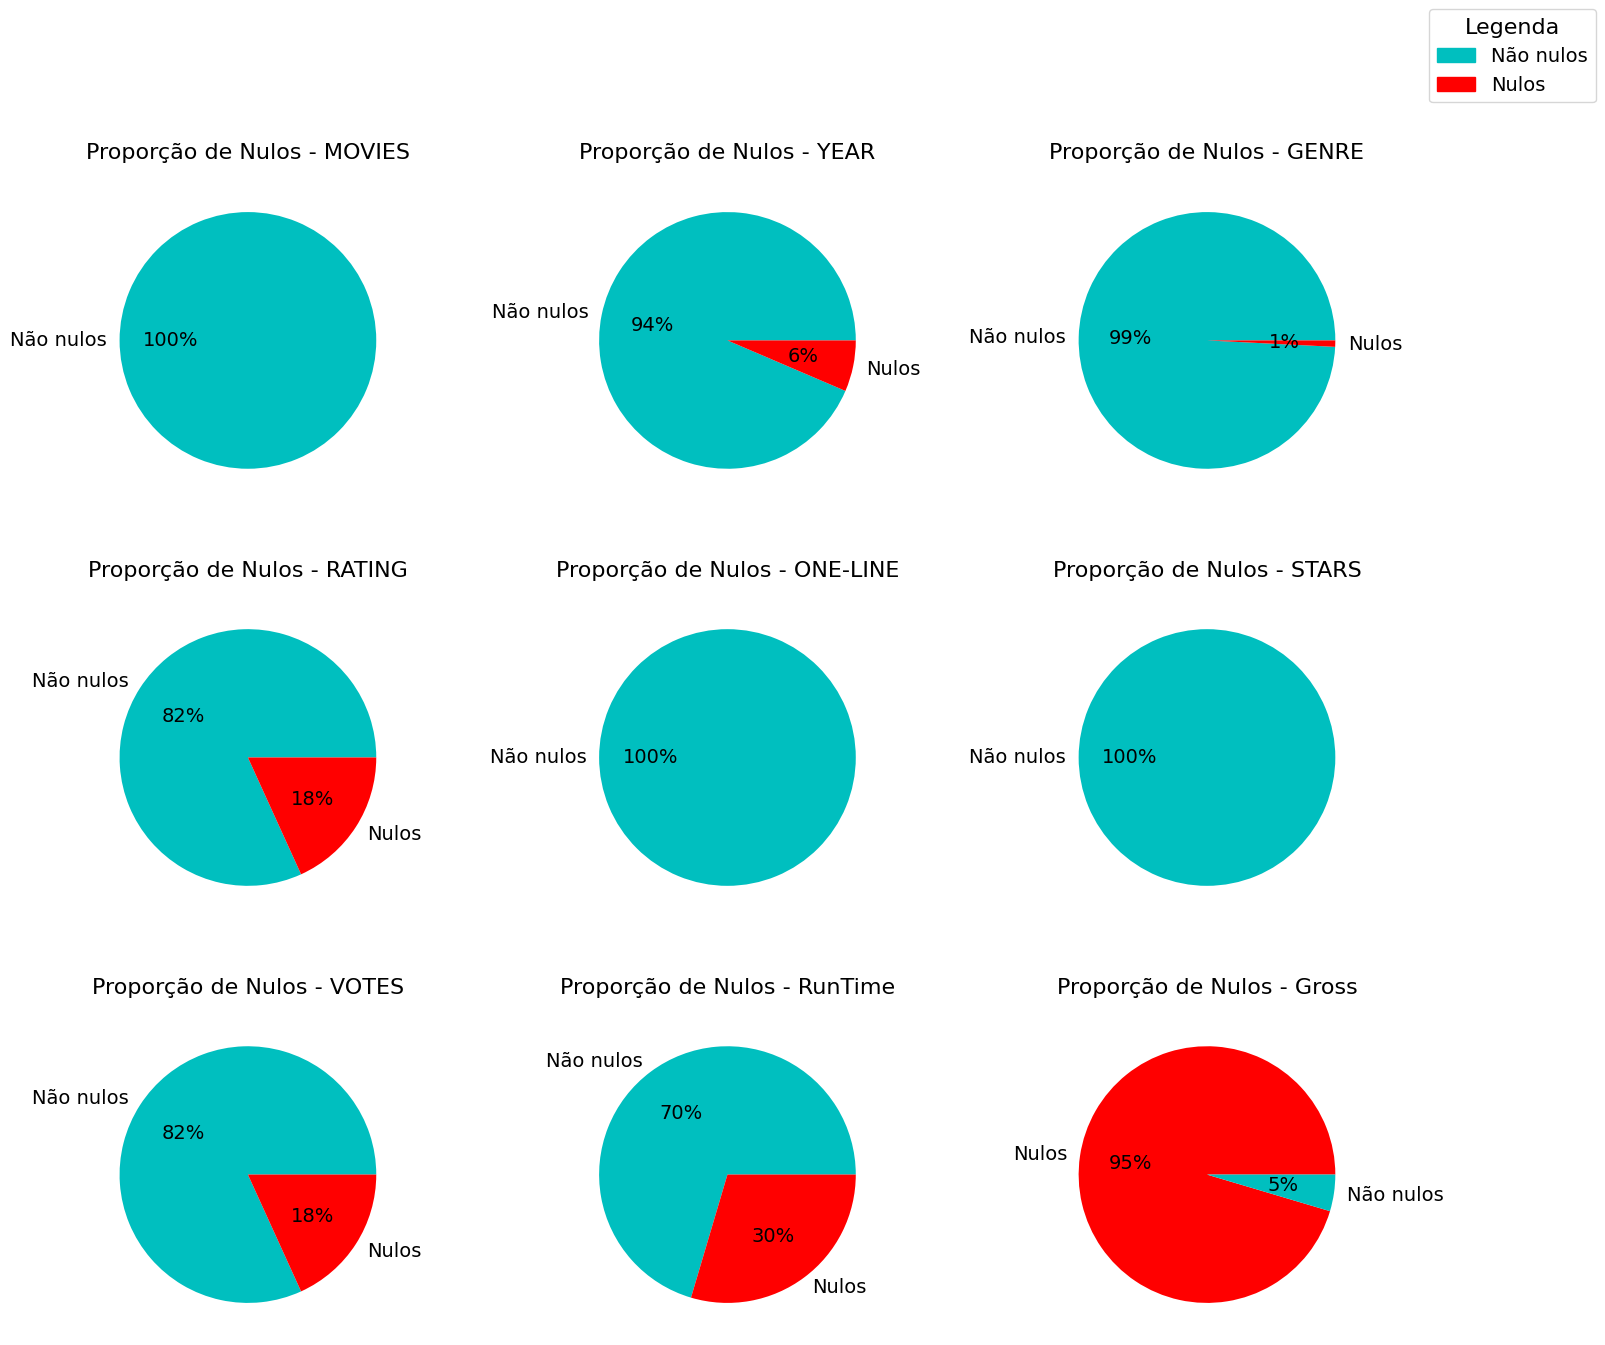

In [9]:
colors_map = ["c", "red"];
labels_map = ["Não nulos", "Nulos"];
fig, axes = plt.subplots(3, 3, figsize=(18, 15));
plt.rcParams.update({'font.size': 14, 'axes.titlesize': 16})

for ax, col_name in enumerate(main_df.columns):

  row = ax // 3;
  col = ax % 3;


  labels = [labels_map[label] for label in main_df[col_name].isnull().value_counts().index];
  colors = [colors_map[color] for color in main_df[col_name].isnull().value_counts().index];

  axes[row, col].pie(main_df[col_name].isnull().value_counts(), autopct='%.0f%%', labels=labels, colors=colors);
  axes[row, col].set_title(f"Proporção de Nulos - {col_name}", pad=15);

legend_handles = [
    mpatches.Patch(color=colors_map[0], label=labels_map[0]),
    mpatches.Patch(color=colors_map[1], label=labels_map[1])
]

fig.legend(handles=legend_handles, title="Legenda", fontsize=14, title_fontsize=16)

plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.show()

Como sugere o gráfico de pizza para a coluna Gross (relativo ao faturamento do filme), a quantidade exorbitante de campos nulos aponta para a não remoção das linhas os contenham. Esta e as demais colunas precisarão de uma análise mais cuidadosa, que permitirá decidir entre o preenchimento de informações ou remoção de registros.

In [10]:
main_df.duplicated().sum()

np.int64(431)

### 1.3. Detecção de outliers

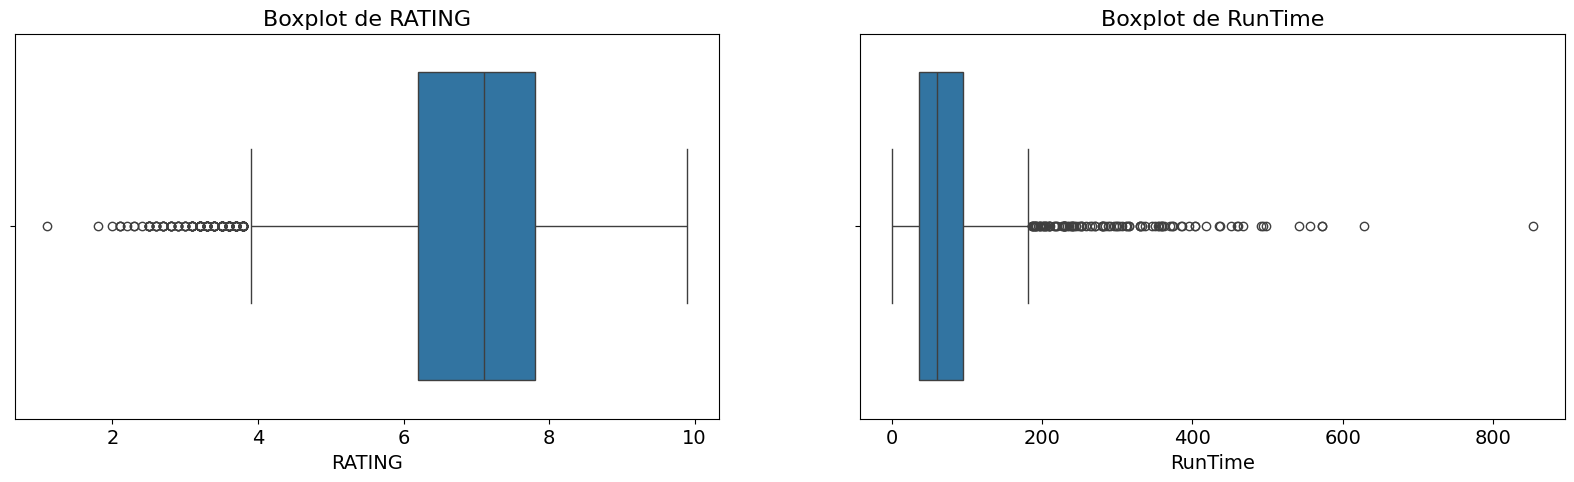

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5));

for ax, col in enumerate(quant_df.columns):
  sns.boxplot(x=quant_df[col], ax=axes[ax])
  axes[ax].set_title(f'Boxplot de {col}')

Os outliers apontados por cada um dos boxplots sugere que há valores numéricos a serem analisados posteriormente

In [12]:
skewed_data = quant_df.skew();
skewed_data

RATING    -0.701921
RunTime    3.642299
dtype: float64

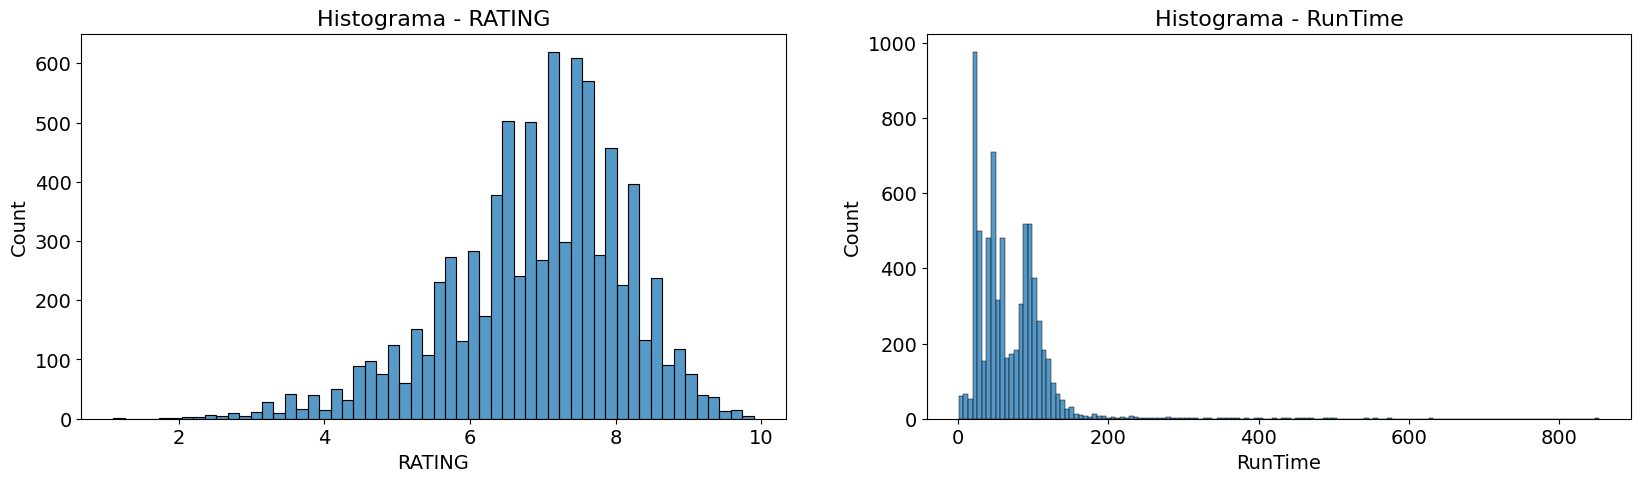

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=len(skewed_data), figsize=(20, 5));

for i, column in enumerate(skewed_data.index):
  sns.histplot(main_df[column], ax=axes[i]);
  axes[i].set_title(f'Histograma - {column}');

Ambos os histogramas sugerem uma assimetria na distribuição destes dados, o que indica que a média não é uma boa medida para tratamento de outliers ou valores faltantes.

### 1.4. Verificação de inconsistências


#### 1.4.1. Coluna YEAR

In [14]:
main_df.YEAR.unique()

array(['(2021)', '(2021– )', '(2010–2022)', '(2013– )', '(2020– )',
       '(2006–2013)', '(2019– )', '(2016–2021)', '(2011– )', '(2005– )',
       '(2008–2013)', '(2017– )', '(2017–2021)', '(2016– )',
       '(1994–2004)', '(2014– )', '(2013–2020)', '(2015– )',
       '(2005–2020)', '(2013–2022)', '(2003– )', '(2009–2020)',
       '(I) (2018– )', '(2010–2015)', '(2011–2019)', '(2015–2020)',
       '(2005–2014)', '(2009–2015)', '(2008–2014)', '(2016–2018)',
       '(2009–2017)', '(2020)', '(2018–2021)', '(2017–2020)',
       '(1987–1994)', '(2018– )', '(2012– )', '(2014–2020)',
       '(2011–2018)', '(2005–2017)', '(2017)', '(2007–2015)',
       '(2000–2007)', '(II) (2007– )', '(1993)', '(1999–2022)',
       '(2015–2018)', '(2014–2019)', '(2016)', '(2012–2020)',
       '(2013–2019)', '(2007–2012)', '(2011–2020)', '(2010–2017)',
       '(2000–2015)', '(2015–2021)', '(2001)', '(1997– )', '(2011–2017)',
       '(1993–1999)', '(1989–1998)', '(2010–2013)', '(2010–2020)',
       '(2003–2019)

In [15]:
# Padrão que verifica se o ano está no formato (YYYY) | (YYYY–YYYY) | (YYYY– )
# Note que há um espaço em branco depois do último formato
years_regex = "^\\(\\d{4}(?:[-–]\\d{4}|[-–] )?\\)$";

# # Para conhecimento, estas seriam as regex para cada formato de data
# # Um detalhe interessaante é que o formato utiliza um hífen (–), que é
# # diferente do dash (-) do (meu) teclado. Neste caso, optamos por verificar
# # ambos os caracteres (feito por esse código [-–]).

# # (YYYY)
# yr_regex_yyyy = "^\\(\\d{4}\\)$";

# # (YYYY– )
# yr_regex_yyyy_ = "^\\(\\d{4}[-–] \\)$";

# # (YYYY–YYYY)
# yr_regex_yyyy_yyyy = "^\\(\\d{4}[-–]\\d{4}\\)$";

main_df.YEAR.str.contains(years_regex, regex=True).value_counts()

YEAR
True     8307
False    1048
Name: count, dtype: int64

Como a análise da coluna sugere, existem anos que contém "ruídos" como algarismos romanos ou informações complementares, como "TV Special", "TV Movie", "Video", dentre outros.

#### 1.4.2. Coluna GENRE

In [16]:
main_df['GENRE'].unique()

array(['\nAction, Horror, Thriller            ',
       '\nAnimation, Action, Adventure            ',
       '\nDrama, Horror, Thriller            ',
       '\nAnimation, Adventure, Comedy            ',
       '\nAction, Crime, Horror            ',
       '\nAction, Crime, Drama            ',
       '\nDrama, Romance            ',
       '\nCrime, Drama, Mystery            ', '\nComedy            ',
       '\nAction, Adventure, Thriller            ',
       '\nCrime, Drama, Fantasy            ',
       '\nDrama, Horror, Mystery            ',
       '\nComedy, Drama, Romance            ',
       '\nCrime, Drama, Thriller            ', '\nDrama            ',
       '\nComedy, Drama            ',
       '\nDrama, Fantasy, Horror            ',
       '\nComedy, Romance            ',
       '\nAction, Adventure, Drama            ',
       '\nCrime, Drama            ',
       '\nDrama, History, Romance            ',
       '\nHorror, Mystery            ', '\nComedy, Crime            ',
     

É nítida a presença de espaços vazios adicionais, que serão tratados posteriormente.


#### 1.4.3. Coluna RATING

In [17]:
rating = main_df['RATING'].unique()
rating

array([6.1, 5. , 8.2, 9.2, nan, 7.6, 6.8, 8.6, 7.9, 7.4, 6. , 8.1, 6.2,
       5.4, 8. , 7.5, 9.4, 8.3, 8.7, 8.9, 8.8, 8.5, 8.4, 6.7, 7.7, 9. ,
       5.8, 3.3, 7.8, 5.7, 6.6, 6.9, 6.5, 7.1, 5.6, 7.3, 9.1, 7.2, 6.4,
       9.3, 7. , 6.3, 3.7, 5.5, 4.6, 4.8, 5.3, 4.7, 5.9, 5.1, 4.9, 2.7,
       4.4, 3.1, 4.5, 4.2, 3.8, 5.2, 2.8, 3.5, 4.3, 3.2, 1.1, 3.9, 4. ,
       3.4, 2.6, 3.6, 3. , 2.5, 2.2, 2.9, 4.1, 2.1, 2. , 2.3, 2.4, 1.8,
       9.6, 9.5, 9.7, 9.9, 9.8])

Há algumas notas não informadas. Pode ser um dado a ser avaliado.


#### 1.4.4. Coluna ONE-LINE

In [18]:
details = main_df['ONE-LINE'].unique()
details

array(['\nA woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.',
       '\nThe war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.',
       '\nSheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.',
       ...,
       "\nLenore urges Hector to not test Camilla's patience. Belmont and Sypha cross paths with Zamfir, a fearsome guard with a suspicious mind.",
       '\nActor Brian Tyree Henry ("Godzilla vs. Kong", "Atlanta", "The Woman in the Window"); guest co-hosts Jerry O\'Connell and Justin Baldoni;',
       "\nAs Paxton's mixed messages have Devi questioning herself, the upcoming winter dance offers a chance to determine where she stands- and what she needs."],
      shape=(8688,), dtype=object)

As sinopses possuem new lines e podem conter outros caracteres de escape. É preciso limpá-los.


RunTime tem cauda longa à direita e Rating é levemente assimétrico à esquerda.

#### 1.4.5. Coluna STARS

In [19]:
main_df["STARS"].unique()

array(['\n    Director:\nPeter Thorwarth\n| \n    Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Setti\n',
       '\n            \n    Stars:\nChris Wood, \nSarah Michelle Gellar, \nLena Headey, \nMark Hamill\n',
       '\n            \n    Stars:\nAndrew Lincoln, \nNorman Reedus, \nMelissa McBride, \nLauren Cohan\n',
       ...,
       '\n    Director:\nOrlando von Einsiedel\n| \n    Star:\nPrince Harry\n',
       '\n    Director:\nJovanka Vuckovic\n| \n    Stars:\nMorgan Taylor Campbell, \nIñaki Godoy, \nRhianna Jagpal, \nSiddhartha Minhas\n',
       '\n    Director:\nJovanka Vuckovic\n| \n    Stars:\nMorgan Taylor Campbell, \nJennifer Cheon Garcia, \nIñaki Godoy, \nRhianna Jagpal\n'],
      shape=(7877,), dtype=object)

Esta coluna possui uma série de nomes do elenco. Será preciso corrigir a presença destes new lines.

In [20]:
# É preciso ter informação de diretor ou estrelas. Então, neste caso
# vamos averiguar quais valores da coluna STARS não seguem esse padrão
# e analisar o motivo posteriormente, para decidir como limpar
rexp = r"^(?=[\s\S]*?\b(?:Directors?|Stars?)\b)(?:[\s\S]*?\bDirectors?\b)?[\s\S]*?(?:\bStars?\b)?[\s\S]*$"

mask = main_df.STARS.str.contains(rexp, regex=True, na=False)

false_check = main_df[~mask]
false_check

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
24,He-Man and the Masters of the Universe,(2021– ),"\nAnimation, Action, Adventure",NaN,\nEternia's Prince Adam discovers the power of...,\n,NaN,NaN,NaN
1027,Myth & Mogul: John DeLorean,(2021– ),"\nDocumentary, Biography, Crime",7.0,"\nIn the automotive world, John DeLorean rose ...",\n,213,NaN,NaN
1380,Love is Blind: After the Altar,(2021– ),\nReality-TV,5.4,"\nCouples from ""Love is Blind"" celebrate their...",\n,39,45.0,NaN
1419,Avatar: The Last Airbender,NaN,"\nAction, Adventure, Fantasy",NaN,\nLive-action adaptation of the animated serie...,\n,NaN,NaN,NaN
1454,Cocaine Cowboys: The Kings of Miami,(2021),"\nDocumentary, Crime, History",NaN,\nTwo childhood friends go from high school dr...,\n,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9972,Sonic Prime,(2022– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9973,Sonic Prime,(2022– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9974,Sonic Prime,(2022– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9986,The Last Kingdom,(2015– ),"\nAction, Drama, History",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN


In [21]:
false_check.STARS.unique()

array(['\n'], dtype=object)

Como mostrado na tabela e no resultado acima, as linhas que não contém informação do diretor e do elenco contém apenas new lines, o que exigirá algum tratamento.

#### 1.4.6. Coluna VOTES

In [22]:
votes = main_df['VOTES'].unique()
votes

array(['21,062', '17,870', '885,805', ..., '5,868', '6,873', '911'],
      shape=(4130,), dtype=object)

É perceptível que o número de avaliações dadas ao filme ou série é dada como *string*. Neste caso, será preciso converter para um valor numérico e, inclusive, analisar a presença de outliers e possíveis inconsistências.

#### 1.4.7. Coluna RunTime

In [23]:
runtime = main_df['RunTime'].unique()
runtime

array([121.,  25.,  44.,  23.,  nan,  50., 110.,  53.,  30., 114.,  42.,
       107.,  60.,  41.,  49.,  51., 109.,  22.,  43., 136.,  46.,  45.,
        58.,  24.,  70.,  64., 148., 395., 101.,  95.,  32., 118.,  47.,
        31., 104., 127.,  54.,  92.,  88.,  59.,  55., 178.,  16.,  48.,
        99., 124., 151., 100.,  40., 149., 119.,  20.,  87., 111.,  91.,
       117., 135., 129., 113.,  15.,  85., 169.,  97., 116., 138., 137.,
       209., 201., 123.,  96., 572., 467., 140.,  56., 112., 125., 145.,
       128., 147.,  90.,  98.,  26., 115., 156., 179., 108.,  34.,  11.,
       152.,  94., 133., 298.,  28., 126., 102., 106., 385., 122., 452.,
       120., 494., 240., 134.,  80.,  89.,  35., 216., 296., 143., 164.,
       386., 363., 150., 105., 131.,  65., 103.,  86.,  52., 356., 154.,
       130., 491., 132.,  93.,  82., 370.,  18., 228.,  84., 280.,  78.,
       316., 264.,  83.,  81., 270., 197., 347., 267.,  37., 230., 233.,
        21., 220., 331.,  39.,   9., 281.,  10., 55

O runtime nada mais é do que a duração da série ou filme, dada em minutos. Alguma inconsistência pode ser abordada, ou mesmo a falta de algum valor.

#### 1.4.8. Coluna Gross

In [24]:
main_df.Gross.unique()

array([nan, '$75.47M', '$402.45M', '$89.22M', '$315.54M', '$57.01M',
       '$260.00M', '$132.38M', '$167.77M', '$404.52M', '$15.07M',
       '$70.10M', '$210.61M', '$327.48M', '$390.53M', '$303.00M',
       '$56.63M', '$58.06M', '$353.01M', '$46.89M', '$7.00M', '$377.85M',
       '$107.83M', '$403.71M', '$316.83M', '$100.55M', '$28.26M',
       '$188.76M', '$213.52M', '$226.01M', '$408.08M', '$10.06M',
       '$14.84M', '$168.05M', '$183.64M', '$342.55M', '$96.52M',
       '$140.22M', '$172.56M', '$56.95M', '$330.36M', '$17.80M', '$0.20M',
       '$56.82M', '$66.21M', '$75.61M', '$4.56M', '$106.58M', '$5.02M',
       '$22.68M', '$102.92M', '$110.52M', '$504.01M', '$26.86M', '$2.00M',
       '$32.73M', '$33.80M', '$400.74M', '$19.02M', '$36.26M', '$6.67M',
       '$45.51M', '$75.66M', '$0.33M', '$4.00M', '$20.16M', '$95.86M',
       '$176.48M', '$126.66M', '$80.10M', '$42.34M', '$0.04M', '$4.71M',
       '$117.72M', '$229.09M', '$33.70M', '$97.69M', '$21.15M', '$27.85M',
       '$25.02

Neste caso, são apresentados os faturamentos de cada filme, por ser o tipo de mídia que revela esta informação. Por serem informações monetárias, provavelmente não precisarão de algum tratamento. Além disso, a quantidade de valores nulos desta coluna indica que a mesma pode ser desconsiderada do dataset.

## 2. Limpeza e Preparação

### 2.1. Limpeza de filmes sem gênero e anos de lançamento ou duração

In [25]:
df_na_dropped = main_df.dropna(subset=['GENRE', 'YEAR'])
df_na_dropped

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n \n Stars:\nMorgan Taylor Camp...,NaN,NaN,NaN
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,NaN,NaN,NaN
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN


In [26]:
df_na_dropped.shape

(9316, 9)

Filmes sem ano de lançamento ou gênero não foram considerados interessantes para manter o dataset informativo.

### 2.2. Legibilizando anos de lançamento ou duração

In [27]:
def convert_year(year):
    years = re.findall(r'\d{4}', year)

    # caso (2013)
    if len(years) == 1:
        if "–" in year:  # (2013– )
            return [years[0], "Still airing"]
        else:
            y = years[0]
            return [y, y]

    # caso (2013–2018)
    if len(years) >= 2:
        return [years[0], years[1]]

    return [None, None]

In [28]:
df_cleaned = df_na_dropped.copy()
df_cleaned[['START_YEAR', 'END_YEAR']] = (
    df_cleaned['YEAR']
    .apply(convert_year)
    .apply(pd.Series)
)

df_cleaned =  df_cleaned.dropna(subset=['START_YEAR', 'END_YEAR'])
df_cleaned

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,START_YEAR,END_YEAR
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN,2021,2021
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN,2021,Still airing
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN,2010,2022
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN,2013,Still airing
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN,2021,2021
...,...,...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n \n Stars:\nMorgan Taylor Camp...,NaN,NaN,NaN,2021,Still airing
9995,Arcane,(2021– ),"\nAnimation, Action, Adventure",NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN,2021,Still airing
9996,Heart of Invictus,(2022– ),"\nDocumentary, Sport",NaN,\nAdd a Plot\n,\n Director:\nOrlando von Einsiedel\n| \n ...,NaN,NaN,NaN,2022,Still airing
9997,The Imperfects,(2021– ),"\nAdventure, Drama, Fantasy",NaN,\nAdd a Plot\n,\n Director:\nJovanka Vuckovic\n| \n Sta...,NaN,NaN,NaN,2021,Still airing


In [29]:
df_cleaned.shape

(9227, 11)

Para facilitar a compreensão do ano de lançamento e encerramento (em séries, sobretudo), foi feito um tratamento para separar esta informação em duas colunas distintas.

### 2.3. Tratamento de informações nulas ou de difícil leitura

Primeiramente, para lidar com valores de RunTime faltantes, pode ser feita a coleta de durações com base no gênero do filme e preencher valores nulos com base na média ou mediana do gênero do filme ou série.

In [30]:
df_cleaned['GENRE'] = df_cleaned['GENRE'].str.strip()

In [31]:
genre_runtime = (
    df_cleaned
    .assign(GENRE=df_cleaned["GENRE"].str.split(", "))
    .explode("GENRE")
    .groupby("GENRE")["RunTime"]
    .mean()
)
genre_runtime

GENRE
Action          57.868974
Adventure       51.184801
Animation       34.361181
Biography      100.501961
Comedy          63.153882
Crime           77.873003
Documentary     79.429719
Drama           75.590713
Family          60.020202
Fantasy         64.545692
Film-Noir       91.083333
Game-Show       42.189189
History         91.766667
Horror          84.522727
Music           81.956790
Musical         87.714286
Mystery         72.324534
News            92.375000
Reality-TV      44.767568
Romance         77.426180
Sci-Fi          73.523404
Short           21.133333
Sport           75.519685
Talk-Show       46.295775
Thriller        84.382353
War            102.022222
Western        103.904762
Name: RunTime, dtype: float64

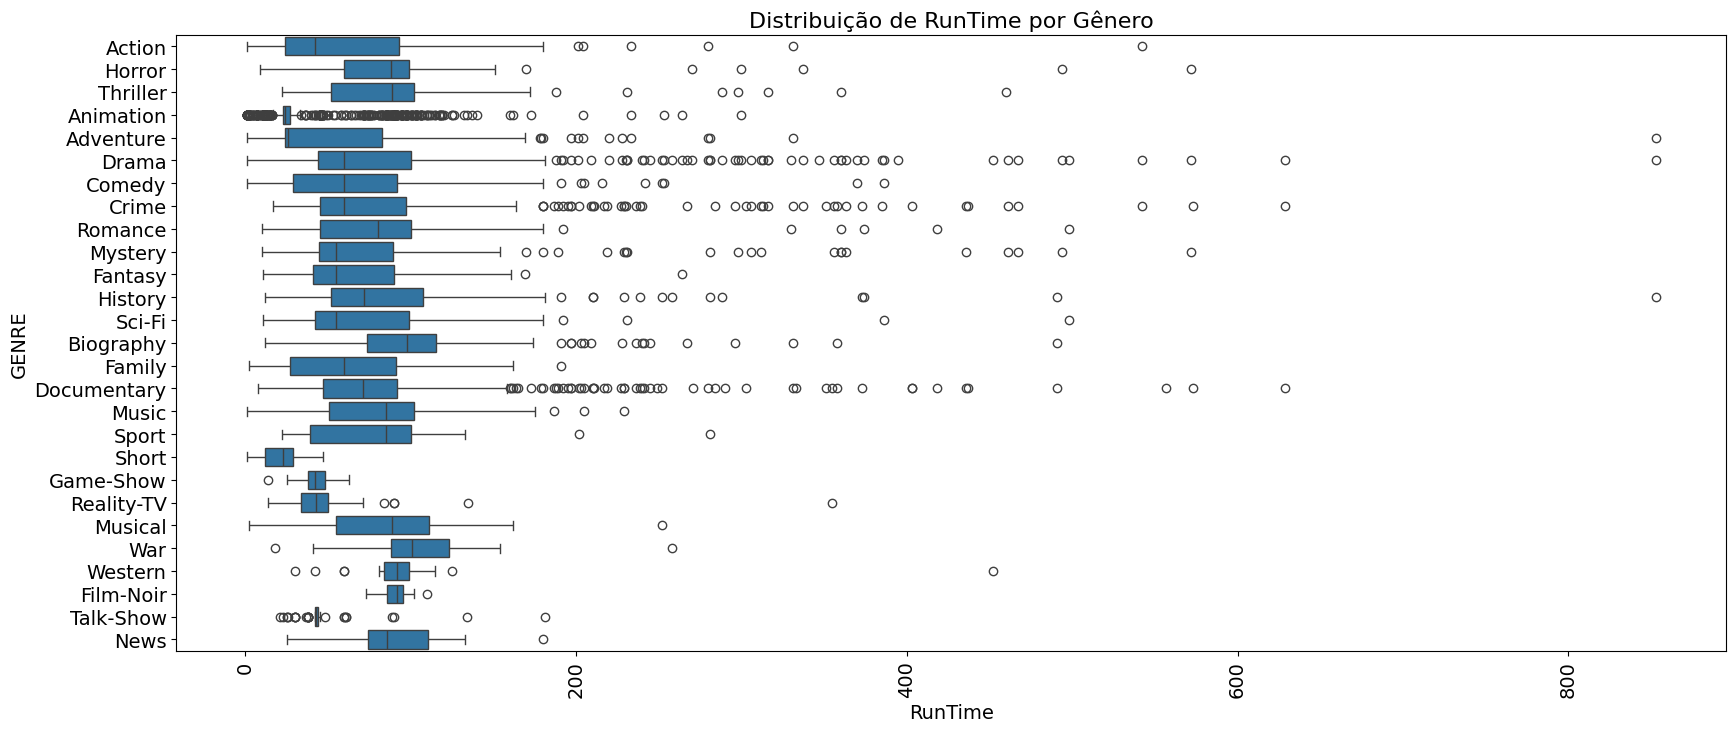

In [32]:
df_exploded = df_cleaned.assign(GENRE=df_cleaned["GENRE"].str.split(", ")).explode("GENRE").reset_index(drop=True)

plt.figure(figsize=(20, 8))
sns.boxplot(data=df_exploded, x="RunTime", y="GENRE")
plt.xticks(rotation=90)
plt.title("Distribuição de RunTime por Gênero")
plt.show()

Como a visualização sugere, pela quantidade de outliers em diversos gêneros, a mediana se mostra como uma medida mais confiável para preencher valores de runtime nulos. Este tipo de tratamento é evidenciado na função abaixo.

In [33]:
def estimate_runtime(genres):
    genre_list = genres.split(", ")
    values = genre_runtime.loc[
        genre_runtime.index.intersection(genre_list)
    ]

    if len(values) == 0:
        return None

    return values.median()

In [34]:
df_cleaned['ONE-LINE'] = df_cleaned['ONE-LINE'].str.strip().replace("Add a Plot", "")
df_cleaned['STARS'] = df_cleaned['STARS'].str.strip().replace("\n", "")
df_cleaned['VOTES'] = df_cleaned['VOTES'].str.replace(",", "").astype(float)
df_cleaned['RATING'] = df_cleaned['RATING'].fillna(5)
df_cleaned['VOTES'] = df_cleaned['VOTES'].fillna(0)
df_cleaned['RunTime'] = df_cleaned['RunTime'].fillna(df_cleaned['GENRE'].apply(estimate_runtime))
df_cleaned

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,START_YEAR,END_YEAR
0,Blood Red Sky,(2021),"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced in...,Director:\nPeter Thorwarth\n| \n Stars:\nPe...,21062.0,121.000000,NaN,2021,2021
1,Masters of the Universe: Revelation,(2021– ),"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may b...,"Stars:\nChris Wood, \nSarah Michelle Gellar, \...",17870.0,25.000000,NaN,2021,Still airing
2,The Walking Dead,(2010–2022),"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a com...,"Stars:\nAndrew Lincoln, \nNorman Reedus, \nMel...",885805.0,44.000000,NaN,2010,2022
3,Rick and Morty,(2013– ),"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits o...,"Stars:\nJustin Roiland, \nChris Parnell, \nSpe...",414849.0,23.000000,NaN,2013,Still airing
4,Army of Thieves,(2021),"Action, Crime, Horror",5.0,"A prequel, set before the events of Army of th...",Director:\nMatthias Schweighöfer\n| \n Star...,0.0,77.873003,NaN,2021,2021
...,...,...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,(2021– ),"Adventure, Drama, Fantasy",5.0,,"Stars:\nMorgan Taylor Campbell, \nChris Cope, ...",0.0,64.545692,NaN,2021,Still airing
9995,Arcane,(2021– ),"Animation, Action, Adventure",5.0,,,0.0,51.184801,NaN,2021,Still airing
9996,Heart of Invictus,(2022– ),"Documentary, Sport",5.0,,Director:\nOrlando von Einsiedel\n| \n Star...,0.0,77.474702,NaN,2022,Still airing
9997,The Imperfects,(2021– ),"Adventure, Drama, Fantasy",5.0,,Director:\nJovanka Vuckovic\n| \n Stars:\nM...,0.0,64.545692,NaN,2021,Still airing


Além das alterações mencionadas para o runtime, para a limpeza do dataset, foram realizadas as seguintes transformações:
- as sinopses (one-line), tiveram seu "Add a plot" padrão convertidos para campos vazios, por já representarem nenhuma informação (é um placeholder)
- a listagem do elenco teve caracteres de new line removidos;
- a quantidade de avaliações foi convertida para um número ao invés de string;
- os ratings nulos foram preenchidos com o valor 5, por ser a mediana entre 0 e 10;
- filmes sem informações de avaliação pública foram preenchidos com o valor 0, por representar que não há dados sobre esta informação.

In [35]:
df_cleaned.shape

(9227, 11)

### 2.4. Limpeza do dataset

In [36]:
df_cleaned = df_cleaned.dropna(subset=['RunTime'])
df_cleaned

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,START_YEAR,END_YEAR
0,Blood Red Sky,(2021),"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced in...,Director:\nPeter Thorwarth\n| \n Stars:\nPe...,21062.0,121.000000,NaN,2021,2021
1,Masters of the Universe: Revelation,(2021– ),"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may b...,"Stars:\nChris Wood, \nSarah Michelle Gellar, \...",17870.0,25.000000,NaN,2021,Still airing
2,The Walking Dead,(2010–2022),"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a com...,"Stars:\nAndrew Lincoln, \nNorman Reedus, \nMel...",885805.0,44.000000,NaN,2010,2022
3,Rick and Morty,(2013– ),"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits o...,"Stars:\nJustin Roiland, \nChris Parnell, \nSpe...",414849.0,23.000000,NaN,2013,Still airing
4,Army of Thieves,(2021),"Action, Crime, Horror",5.0,"A prequel, set before the events of Army of th...",Director:\nMatthias Schweighöfer\n| \n Star...,0.0,77.873003,NaN,2021,2021
...,...,...,...,...,...,...,...,...,...,...,...
9994,The Imperfects,(2021– ),"Adventure, Drama, Fantasy",5.0,,"Stars:\nMorgan Taylor Campbell, \nChris Cope, ...",0.0,64.545692,NaN,2021,Still airing
9995,Arcane,(2021– ),"Animation, Action, Adventure",5.0,,,0.0,51.184801,NaN,2021,Still airing
9996,Heart of Invictus,(2022– ),"Documentary, Sport",5.0,,Director:\nOrlando von Einsiedel\n| \n Star...,0.0,77.474702,NaN,2022,Still airing
9997,The Imperfects,(2021– ),"Adventure, Drama, Fantasy",5.0,,Director:\nJovanka Vuckovic\n| \n Stars:\nM...,0.0,64.545692,NaN,2021,Still airing


In [37]:
df_cleaned.shape

(9227, 11)

Para remover qualquer ocorrência de filmes ou séries duplicados no dataset, serão adotadas estratégias de concatenação e recálculo das avaliações e quantidade de avaliações públicas, considerando que estas informações publicadas vieram de diferentes fontes.

In [38]:
def join_genres(genres):
    return ', '.join(genres.unique())

In [39]:
def calculate_rating(group):
    return (group["RATING"] * group["VOTES"]).sum() / group["VOTES"].sum()

In [40]:
def concatenate_synopsys(synopsys):
  return '; '.join(synopsys.unique())

In [41]:
def sum_votes(votes):
  return sum(votes)

In [42]:
ds_without_duplicates = (
    df_cleaned
    .groupby(["MOVIES", "YEAR"])
    .apply(lambda g: pd.Series({
        "GENRE": join_genres(g["GENRE"]),
        "RATING": calculate_rating(g),
        "ONE_LINE": concatenate_synopsys(g["ONE-LINE"]),
        "STARS": g["STARS"].iloc[0],
        "VOTES": sum_votes(g["VOTES"]),
        "RunTime": g["RunTime"].mean(),
        "START_YEAR": g["START_YEAR"].iloc[0],
        "END_YEAR": g["END_YEAR"].iloc[0]
    }))
)
ds_without_duplicates = ds_without_duplicates.reset_index()
ds_without_duplicates

,MOVIES,YEAR,GENRE,RATING,ONE_LINE,STARS,VOTES,RunTime,START_YEAR,END_YEAR
0,13 Reasons Why,(2017–2020),"Drama, Mystery, Thriller",6.199350,"The police question Tyler about the guns, leav...",Director:\nRussell Mulcahy\n| \n Stars:\nDy...,16936.0,62.800000,2017,2020
1,1899,(2022– ),"Drama, History, Horror",NaN,,Director:\nBaran bo Odar\n| \n Stars:\nAneu...,0.0,84.522727,2022,Still airing
2,3Below: Tales of Arcadia,(2018–2019),"Animation, Action, Adventure",7.982846,"Left vulnerable after Omen's attack, the royal...",Director:\nAndrew L. Schmidt\n| \n Stars:\n...,1813.0,22.656057,2018,2019
3,50M2,(2021– ),"Comedy, Drama, Thriller",7.289540,"While seeking answers about his parents, Shado...",Director:\nSelçuk Aydemir\n| \n Stars:\nEng...,956.0,49.000000,2021,Still airing
4,7Seeds,(2019–2020),"Animation, Action, Adventure",7.138034,"Convinced that Botan has kidnapped them, Natsu...","Stars:\nMorgan Berry, \nAmber Lee Connors, \nE...",702.0,24.695652,2019,2020
...,...,...,...,...,...,...,...,...,...,...
6292,Ófærð,(2015– ),"Crime, Drama, Mystery",8.100000,"In a remote town in Iceland, Police desperatel...","Stars:\nÓlafur Darri Ólafsson, \nIlmur Kristjá...",17309.0,60.000000,2015,Still airing
6293,Órbita 9,(2017),"Drama, Romance, Sci-Fi",5.900000,Helena is a young girl who spent all her life ...,Director:\nHatem Khraiche\n| \n Stars:\nCla...,7123.0,95.000000,2017,2017
6294,Ôkami to kôshinryô,(2008–2009),"Animation, Adventure, Fantasy",8.000000,Kraft Lawrence goes from town to town to make ...,"Stars:\nJun Fukuyama, \nAmi Koshimizu, \nBrina...",3959.0,24.000000,2008,2009
6295,Öldür Beni Sevgilim,(2019),"Comedy, Romance",4.400000,Can the excitement of the national lottery sav...,Director:\nSenol Sönmez\n| \n Stars:\nMurat...,1568.0,104.000000,2019,2019


In [43]:
ds_without_duplicates.shape

(6297, 10)

Por fim, filmes sem avaliações serão descartados, para manter, no dataset, para cada mídia, informações relevantes.

In [44]:
df_rated = ds_without_duplicates.dropna(subset=['RATING', 'VOTES'], ignore_index=True)
df_rated

,MOVIES,YEAR,GENRE,RATING,ONE_LINE,STARS,VOTES,RunTime,START_YEAR,END_YEAR
0,13 Reasons Why,(2017–2020),"Drama, Mystery, Thriller",6.199350,"The police question Tyler about the guns, leav...",Director:\nRussell Mulcahy\n| \n Stars:\nDy...,16936.0,62.800000,2017,2020
1,3Below: Tales of Arcadia,(2018–2019),"Animation, Action, Adventure",7.982846,"Left vulnerable after Omen's attack, the royal...",Director:\nAndrew L. Schmidt\n| \n Stars:\n...,1813.0,22.656057,2018,2019
2,50M2,(2021– ),"Comedy, Drama, Thriller",7.289540,"While seeking answers about his parents, Shado...",Director:\nSelçuk Aydemir\n| \n Stars:\nEng...,956.0,49.000000,2021,Still airing
3,7Seeds,(2019–2020),"Animation, Action, Adventure",7.138034,"Convinced that Botan has kidnapped them, Natsu...","Stars:\nMorgan Berry, \nAmber Lee Connors, \nE...",702.0,24.695652,2019,2020
4,A Suitable Boy,(2020– ),"Drama, Romance",6.194289,Lata continues to pursue a relationship with K...,Director:\nMira Nair\n| \n Stars:\nTanya Ma...,893.0,61.084741,2020,Still airing
...,...,...,...,...,...,...,...,...,...,...
5840,Ófærð,(2015– ),"Crime, Drama, Mystery",8.100000,"In a remote town in Iceland, Police desperatel...","Stars:\nÓlafur Darri Ólafsson, \nIlmur Kristjá...",17309.0,60.000000,2015,Still airing
5841,Órbita 9,(2017),"Drama, Romance, Sci-Fi",5.900000,Helena is a young girl who spent all her life ...,Director:\nHatem Khraiche\n| \n Stars:\nCla...,7123.0,95.000000,2017,2017
5842,Ôkami to kôshinryô,(2008–2009),"Animation, Adventure, Fantasy",8.000000,Kraft Lawrence goes from town to town to make ...,"Stars:\nJun Fukuyama, \nAmi Koshimizu, \nBrina...",3959.0,24.000000,2008,2009
5843,Öldür Beni Sevgilim,(2019),"Comedy, Romance",4.400000,Can the excitement of the national lottery sav...,Director:\nSenol Sönmez\n| \n Stars:\nMurat...,1568.0,104.000000,2019,2019


In [45]:
df_rated.shape

(5845, 10)

### 2.5. Análise posterior - identificando possíveis tratamentos

In [46]:
describe_df = df_rated.describe();
describe_df.loc["iqr"] = describe_df.loc["75%"] - describe_df.loc["25%"];
describe_df

,RATING,VOTES,RunTime
count,5845.000000,5.845000e+03,5845.000000
mean,6.637911,2.116317e+04,77.752226
std,1.215704,8.225038e+04,47.325160
min,1.100000,5.000000e+00,1.000000
25%,5.900000,4.120000e+02,48.000000
50%,6.800000,1.637000e+03,77.426180
75%,7.500000,7.364000e+03,98.000000
max,9.400000,1.713028e+06,853.000000
iqr,1.600000,6.952000e+03,50.000000


#### 2.5.1. Votes - Analisando possíveis outliers

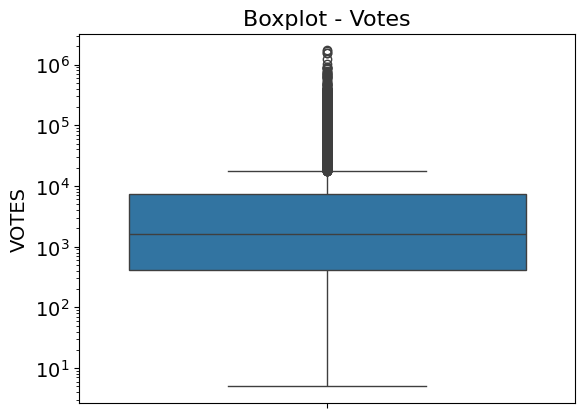

In [47]:
sns.boxplot(df_rated["VOTES"], orient="v")
plt.title("Boxplot - Votes")
plt.yscale('log')

In [48]:
votes_over_q3_df = df_rated[df_rated.VOTES >= (describe_df.loc["75%", "VOTES"] + 1.5 * describe_df.loc["iqr", "VOTES"])]
votes_over_q3_df.sort_values(by="VOTES", ascending=False)

,MOVIES,YEAR,GENRE,RATING,ONE_LINE,STARS,VOTES,RunTime,START_YEAR,END_YEAR
5016,The Lord of the Rings: The Fellowship of the Ring,(2001),"Action, Adventure, Drama",8.8,A meek Hobbit from the Shire and eight compani...,Director:\nPeter Jackson\n| \n Stars:\nElij...,1713028.0,178.0,2001,2001
5017,The Lord of the Rings: The Return of the King,(2003),"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,Director:\nPeter Jackson\n| \n Stars:\nElij...,1691777.0,201.0,2003,2003
1024,Breaking Bad,(2008–2013),"Crime, Drama, Thriller",9.4,A high school chemistry teacher diagnosed with...,"Stars:\nBryan Cranston, \nAaron Paul, \nAnna G...",1552311.0,49.0,2008,2013
5018,The Lord of the Rings: The Two Towers,(2002),"Action, Adventure, Drama",8.7,While Frodo and Sam edge closer to Mordor with...,Director:\nPeter Jackson\n| \n Stars:\nElij...,1529752.0,179.0,2002,2002
4823,The Departed,(2006),"Crime, Drama, Thriller",8.5,An undercover cop and a mole in the police att...,Director:\nMartin Scorsese\n| \n Stars:\nLe...,1227522.0,151.0,2006,2006
...,...,...,...,...,...,...,...,...,...,...
1455,Death Warrant,(1990),"Action, Crime, Mystery",5.7,"In a violent and corrupt prison, decorated cop...",Director:\nDeran Sarafian\n| \n Stars:\nJea...,17926.0,89.0,1990,1990
686,Ascension,(2014),"Drama, Sci-Fi",7.2,A young woman's murder causes the subjects of ...,"Stars:\nTricia Helfer, \nGil Bellows, \nBrian ...",17926.0,231.0,2014,2014
5801,Zeitgeist: Moving Forward,(2011),Documentary,8.1,A feature length documentary work which presen...,Director:\nPeter Joseph\n| \n Stars:\nPeter...,17918.0,161.0,2011,2011
1305,Crazy Ex-Girlfriend,(2015–2019),"Comedy, Musical",7.8,A young woman abandons a choice job at a law f...,"Stars:\nRachel Bloom, \nDonna Lynne Champlin, ...",17902.0,42.0,2015,2019


Sobre os resultados acima, é esperado que blockbusters, como o filme The Lord of the Rings, alcancem um grande número de votações. Neste caso, este tipo de informação precisa ser tratada.

In [49]:
votes_below_q1_df = df_rated[df_rated.VOTES <= (describe_df.loc["25%", "VOTES"] - 1.5 * describe_df.loc["iqr", "VOTES"])]
votes_below_q1_df.sort_values(by="VOTES", ascending=True)

,MOVIES,YEAR,GENRE,RATING,ONE_LINE,STARS,VOTES,RunTime,START_YEAR,END_YEAR


Como não há nenhum outlier abaixo do primeiro quartil, não há nada que precise ser feito.

#### 2.5.2. RunTime - analisando possíveis outliers

Text(0.5, 1.0, 'Boxplot - RunTime')

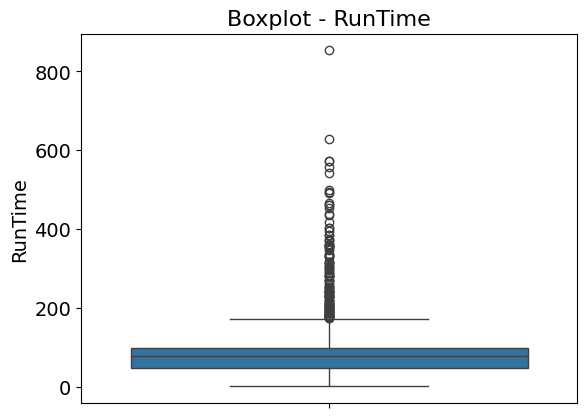

In [50]:
sns.boxplot(df_rated["RunTime"], orient="v")
plt.title("Boxplot - RunTime")

In [51]:
runtime_over_q3_df = df_rated[df_rated.RunTime >= (describe_df.loc["75%", "RunTime"] + 1.5 * describe_df.loc["iqr", "RunTime"])]
runtime_over_q3_df.sort_values(by="RunTime", ascending=False)

,MOVIES,YEAR,GENRE,RATING,ONE_LINE,STARS,VOTES,RunTime,START_YEAR,END_YEAR
1696,El tiempo entre costuras,(2013–2014),"Adventure, Drama, History",8.3,Sira Quiroga is a young Spanish dressmaker eng...,"Stars:\nAdriana Ugarte, \nMari Carmen Sánchez,...",3876.0,853.0,2013,2014
4443,Soupçons,(2004–2018),"Documentary, Crime, Drama",7.9,The high-profile murder trial of American nove...,"Stars:\nMichael Peterson, \nDavid Rudolf, \nRo...",20200.0,629.0,2004,2018
4951,The Innocence Files,(2020),"Documentary, Crime",8.0,Cases of wrongful conviction that the Innocenc...,"Stars:\nPeter Neufeld, \nBarry Scheck, \nMicha...",2335.0,573.0,2020,2020
4916,The Haunting of Hill House,(2018),"Drama, Horror, Mystery",8.6,"Flashing between past and present, a fractured...","Stars:\nMichiel Huisman, \nCarla Gugino, \nHen...",195117.0,572.0,2018,2018
1288,Cosmos: A Spacetime Odyssey,(2014),Documentary,9.3,An exploration of our discovery of the laws of...,"Stars:\nNeil deGrasse Tyson, \nStoney Emshwill...",114386.0,557.0,2014,2014
...,...,...,...,...,...,...,...,...,...,...
5018,The Lord of the Rings: The Two Towers,(2002),"Action, Adventure, Drama",8.7,While Frodo and Sam edge closer to Mordor with...,Director:\nPeter Jackson\n| \n Stars:\nElij...,1529752.0,179.0,2002,2002
5016,The Lord of the Rings: The Fellowship of the Ring,(2001),"Action, Adventure, Drama",8.8,A meek Hobbit from the Shire and eight compani...,Director:\nPeter Jackson\n| \n Stars:\nElij...,1713028.0,178.0,2001,2001
5081,The Oscars,(2016 TV Special),Music,6.4,The 88th Academy Awards ceremony honors achiev...,Director:\nGlenn Weiss\n| \n Stars:\nChris ...,2063.0,175.0,2016,2016
2361,Houdini,(2014),"Biography, Drama",7.4,Follow the man behind the magic as he finds fa...,"Stars:\nAdrien Brody, \nKristen Connolly, \nEv...",11302.0,174.0,2014,2014


Analisando o RunTime (tempo total da obra em minutos), é perceptível que, como o dataset inclui séries em sua coleção, minutagens grandes são plausíveis. Tomemos como exemplo o El tiempo entre costuras. Ao todo, somando o tempo de cada episódio, a série apresenta, aproximadamente, 14 horas e 13 minutos de duração, o que condiz com o RunTime de 853 minutos.

Neste caso, não se parece necessário tratar este tipo de outlier.

In [52]:
runtime_below_q1_df = df_rated[df_rated.RunTime <= (describe_df.loc["25%", "RunTime"] - 1.5 * describe_df.loc["iqr", "RunTime"])]
runtime_below_q1_df.sort_values(by="RunTime", ascending=True)

,MOVIES,YEAR,GENRE,RATING,ONE_LINE,STARS,VOTES,RunTime,START_YEAR,END_YEAR


Como não há nenhum outlier abaixo do primeiro quartil, não há nada que precise ser feito.

## 3. Dataset final

In [53]:
df_rated

,MOVIES,YEAR,GENRE,RATING,ONE_LINE,STARS,VOTES,RunTime,START_YEAR,END_YEAR
0,13 Reasons Why,(2017–2020),"Drama, Mystery, Thriller",6.199350,"The police question Tyler about the guns, leav...",Director:\nRussell Mulcahy\n| \n Stars:\nDy...,16936.0,62.800000,2017,2020
1,3Below: Tales of Arcadia,(2018–2019),"Animation, Action, Adventure",7.982846,"Left vulnerable after Omen's attack, the royal...",Director:\nAndrew L. Schmidt\n| \n Stars:\n...,1813.0,22.656057,2018,2019
2,50M2,(2021– ),"Comedy, Drama, Thriller",7.289540,"While seeking answers about his parents, Shado...",Director:\nSelçuk Aydemir\n| \n Stars:\nEng...,956.0,49.000000,2021,Still airing
3,7Seeds,(2019–2020),"Animation, Action, Adventure",7.138034,"Convinced that Botan has kidnapped them, Natsu...","Stars:\nMorgan Berry, \nAmber Lee Connors, \nE...",702.0,24.695652,2019,2020
4,A Suitable Boy,(2020– ),"Drama, Romance",6.194289,Lata continues to pursue a relationship with K...,Director:\nMira Nair\n| \n Stars:\nTanya Ma...,893.0,61.084741,2020,Still airing
...,...,...,...,...,...,...,...,...,...,...
5840,Ófærð,(2015– ),"Crime, Drama, Mystery",8.100000,"In a remote town in Iceland, Police desperatel...","Stars:\nÓlafur Darri Ólafsson, \nIlmur Kristjá...",17309.0,60.000000,2015,Still airing
5841,Órbita 9,(2017),"Drama, Romance, Sci-Fi",5.900000,Helena is a young girl who spent all her life ...,Director:\nHatem Khraiche\n| \n Stars:\nCla...,7123.0,95.000000,2017,2017
5842,Ôkami to kôshinryô,(2008–2009),"Animation, Adventure, Fantasy",8.000000,Kraft Lawrence goes from town to town to make ...,"Stars:\nJun Fukuyama, \nAmi Koshimizu, \nBrina...",3959.0,24.000000,2008,2009
5843,Öldür Beni Sevgilim,(2019),"Comedy, Romance",4.400000,Can the excitement of the national lottery sav...,Director:\nSenol Sönmez\n| \n Stars:\nMurat...,1568.0,104.000000,2019,2019


In [54]:
df_rated.shape

(5845, 10)